# Data Wrangling/EDA/Feature Engineering/Data Preprocessing

In [1]:
# Missing Value Treatment

# Scaling Technique

# Outlier Treatment

# Encoding Technique

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("sales_data.csv")
data

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834,14.1
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.2,OUT045,2002,NaN,NaN,Supermarket Type1,549.2850,14.2
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1,OUT035,2004,Small,Tier1,Supermarket Type1,1193.1136,9.5
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1,OUT018,2009,Medium,Tier 2,Supermarket Type2,1845.5976,14.2


# Missing Value Treatment

In [3]:
data.isnull().sum()

Item_Identifier                 0
Item_Weight                   749
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [4]:
#Checking the behaviour data carefully

In [5]:
data.describe()   # statistical five point summary

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7774.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,11.676740,0.066132,140.998838,1997.831867,2181.288914,13.414514
std,5.776851,0.051598,62.258099,8.371760,1706.499616,1.701840
min,0.000000,0.000000,31.300000,1985.000000,33.290000,0.100000
25%,7.720000,0.026989,93.800000,1987.000000,834.247400,13.150000
50%,11.800000,0.053931,142.700000,1999.000000,1794.331000,13.900000
75%,16.500000,0.094585,185.650000,2004.000000,3101.296400,14.300000
max,21.350000,0.328391,266.900000,2009.000000,13086.964800,24.000000


<Axes: ylabel='Density'>

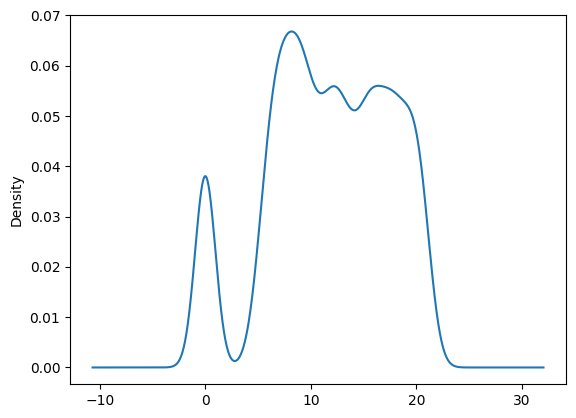

In [6]:
data["Item_Weight"].plot(kind="kde")

<Axes: xlabel='Item_Weight', ylabel='Density'>

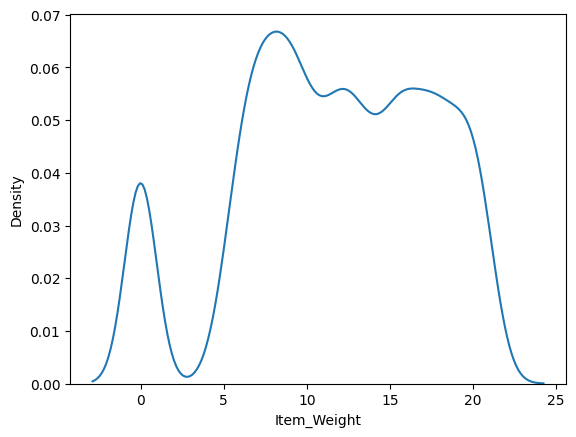

In [7]:
sns.distplot(data["Item_Weight"],hist=False)

In [8]:
data_new=data.copy()

In [9]:
data_new.isnull().sum()

Item_Identifier                 0
Item_Weight                   749
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [10]:
data_new[data_new["Item_Weight"]==0]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
36,FDV20,0.0,Regular,0.059512,Fruits and Vegetables,128.1,OUT027,1985,Medium,Tier 2,Supermarket Type3,2797.6916,12.4
38,FDX10,0.0,Regular,0.123111,Snack Foods,37.0,OUT027,1985,Medium,Tier 2,Supermarket Type3,388.1614,14.3
39,FDB34,0.0,Low Fat,0.026481,Snack Foods,87.6,OUT027,1985,Medium,Tier 2,Supermarket Type3,2180.4950,14.6
49,FDS02,0.0,Regular,0.255395,Dairy,196.9,OUT019,1985,Small,Tier1,Grocery Store,780.3176,14.7
59,FDI26,0.0,Low Fat,0.061082,Canned,180.0,OUT019,1985,Small,Tier1,Grocery Store,892.1720,14.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8485,DRK37,0.0,Low Fat,0.043792,Soft Drinks,189.1,OUT027,1985,Medium,Tier 2,Supermarket Type3,6261.8490,14.7
8487,DRG13,0.0,Low Fat,0.037006,Soft Drinks,164.8,OUT027,1985,Medium,Tier 2,Supermarket Type3,4111.3150,14.5
8488,NCN14,0.0,Low Fat,0.091473,Others,184.7,OUT027,1985,Medium,Tier 2,Supermarket Type3,2756.4120,10.5
8490,FDU44,0.0,Regular,0.102296,Fruits and Vegetables,162.4,OUT019,1985,Small,Tier1,Grocery Store,487.3656,14.7


In [11]:
ind=data_new[data_new["Item_Weight"]==0].index

In [12]:
ind

Index([  36,   38,   39,   49,   59,   62,   63,   64,   77,   83,
       ...
       8458, 8463, 8469, 8472, 8480, 8485, 8487, 8488, 8490, 8504],
      dtype='int64', length=714)

In [13]:
data_new.loc[ind,"Item_Weight"]=np.nan

In [14]:
data_new.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.998838,1997.831867,2181.288914,13.414514
std,4.643456,0.051598,62.258099,8.371760,1706.499616,1.701840
min,4.555000,0.000000,31.300000,1985.000000,33.290000,0.100000
25%,8.773750,0.026989,93.800000,1987.000000,834.247400,13.150000
50%,12.600000,0.053931,142.700000,1999.000000,1794.331000,13.900000
75%,16.850000,0.094585,185.650000,2004.000000,3101.296400,14.300000
max,21.350000,0.328391,266.900000,2009.000000,13086.964800,24.000000


<Axes: ylabel='Density'>

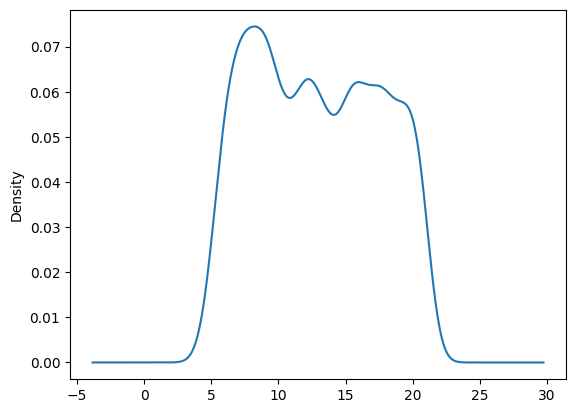

In [15]:
data_new["Item_Weight"].plot(kind="kde")

In [16]:
data_new.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [17]:
749+714

1463

In [18]:
# drop the missing values
# filling the missing values with fixed values
# fill with mean,median,mode
# based on grouping technique

In [19]:
data1=data_new.copy()

In [20]:
data1.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5


In [21]:
data1.dropna(inplace=True) # drop all the missing values

In [22]:
data1.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Profit                       0
dtype: int64

In [23]:
data1.shape

(4650, 13)

In [24]:
((8523-4650)/8523)*100

45.44174586413235

In [25]:
#imputation Technique
data2=data_new.copy()

In [26]:
data2.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

<Axes: ylabel='Density'>

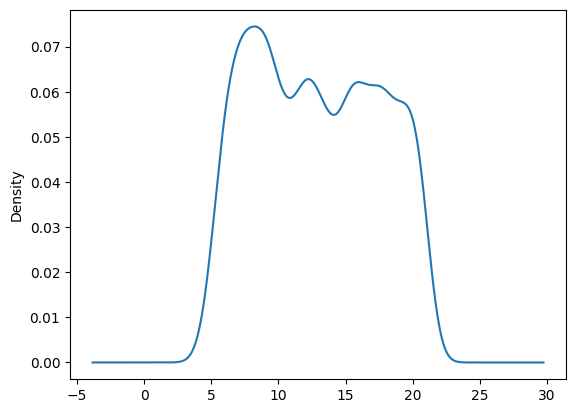

In [27]:
# fill with fixed value
data2["Item_Weight"].plot(kind="kde")

In [28]:
data2["Item_Weight"].fillna(100,inplace=True)

In [29]:
data2.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

<Axes: ylabel='Density'>

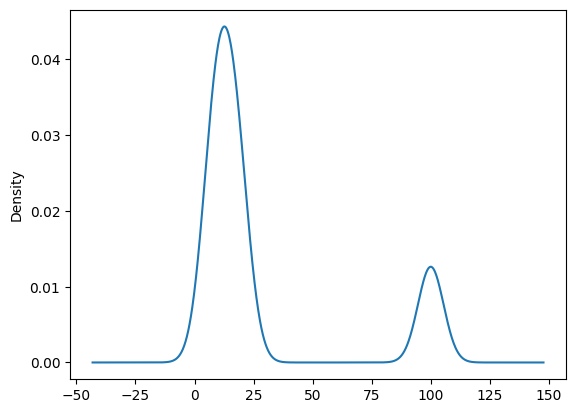

In [30]:
data2["Item_Weight"].plot(kind="kde")

In [31]:
# fill the missing values with mean,median and mode

In [32]:
a=pd.Series([1,5,9,7,1000])
x=a.mean()
print(x)

204.4


In [33]:
y=a.median()
print(y)

7.0


In [34]:
data3=data_new.copy()

In [35]:
data3.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [36]:
#sns.boxplot(data3["Item_Weight"])

In [37]:
# mean
data3["Item_Weight"].fillna(data3["Item_Weight"].median(),inplace=True)


In [38]:
data3.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

<Axes: ylabel='Density'>

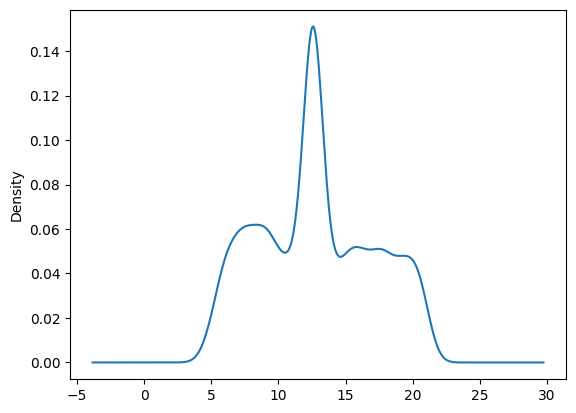

In [39]:
data3["Item_Weight"].plot(kind="kde")

In [40]:
data3["Item_Weight"].median()

np.float64(12.6)

In [41]:
data4=data_new.copy()

In [42]:
# using group technique
data4["Item_Weight"]=data4["Item_Weight"].fillna(data4.groupby("Item_Identifier")["Item_Weight"].transform("mean"))

In [43]:
#data4.groupby("Item_Fat_Content")["Item_Weight"].mean()

In [44]:
data4.isnull().sum()

Item_Identifier                 0
Item_Weight                     4
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [45]:
data4[data4["Item_Weight"].isna()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
927,FDN52,NaN,Regular,0.130933,Frozen Foods,86.9,OUT027,1985,Medium,Tier 2,Supermarket Type3,1569.9564,14.1
1922,FDK57,NaN,Low Fat,0.079904,Snack Foods,120.0,OUT027,1985,Medium,Tier 2,Supermarket Type3,4434.2280,14.5
4187,FDE52,NaN,Regular,0.029742,Dairy,89.0,OUT027,1985,Medium,Tier 2,Supermarket Type3,3453.5046,13.9
5022,FDQ60,NaN,Regular,0.191501,Baking Goods,121.2,OUT019,1985,Small,Tier1,Grocery Store,120.5098,12.3


In [46]:
#data5.groupby("Item_Type")["Item_Weight"].mean()

<Axes: ylabel='Density'>

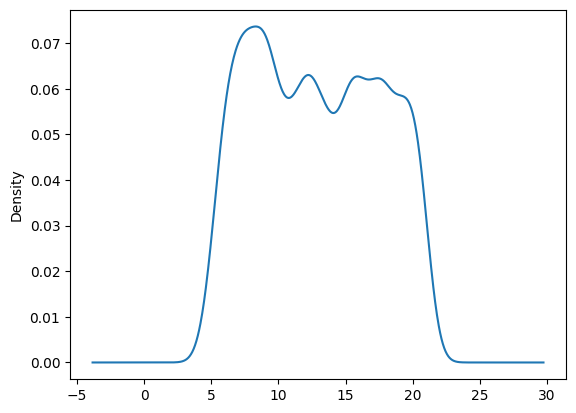

In [47]:
data4["Item_Weight"].plot(kind="kde")

In [48]:
# categorial
#data5=data_new

data4["Outlet_Size"].mode()

0    Medium
Name: Outlet_Size, dtype: object

In [49]:
data4["Outlet_Size"].fillna(data4["Outlet_Size"].mode()[0],inplace=True)

In [50]:
data4.isnull().sum()

Item_Identifier                 0
Item_Weight                     4
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [51]:
data5=data_new.copy()

In [52]:
data5.groupby("Outlet_Size")["Item_Outlet_Sales"].mean()


Outlet_Size
High      2298.995256
Medium    2681.603542
Small     1912.149161
Name: Item_Outlet_Sales, dtype: float64

In [53]:
# #Rule


# ["Item_Outlet_Sales"]<1900----> small
# ["Item_Outlet_Sales"]>2600---->Medium
# others---->high

In [54]:
ind1=data5[data5["Outlet_Size"].isnull()].index

In [55]:
ind1

Index([   3,    8,    9,   25,   28,   30,   33,   45,   46,   47,
       ...
       8493, 8494, 8496, 8500, 8501, 8502, 8508, 8509, 8514, 8519],
      dtype='int64', length=2410)

In [56]:
for i in ind1:
    if data5.loc[i,"Item_Outlet_Sales"]>2600:
        data5.loc[i,"Outlet_Size"]="Medium"
        
    elif data5.loc[i,"Item_Outlet_Sales"]<1900:
        data5.loc[i,"Outlet_Size"]="Small"
        
    else:
        data5.loc[i,"Outlet_Size"]="High"

In [57]:
data5.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type         2050
Outlet_Type                     0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [58]:
data4["Outlet_Location_Type"].mode()

0    Tier 2
Name: Outlet_Location_Type, dtype: object

In [59]:
data4["Outlet_Location_Type"].fillna(data4["Outlet_Location_Type"].mode()[0],inplace=True)

In [60]:
data4.isnull().sum()

Item_Identifier              0
Item_Weight                  4
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Profit                       0
dtype: int64

In [61]:
data4.dropna(inplace=True)

In [62]:
data4.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Profit                       0
dtype: int64

In [63]:
data4.shape

(8519, 13)

# Outlier Treatment

In [64]:
data.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales', 'Profit'],
      dtype='object')

In [65]:
# for i in data.columns:
#     sns.boxplot(data[i])
#     plt.show()

In [66]:
data[["Item_Weight","Item_Visibility","Item_MRP"]]

,Item_Weight,Item_Visibility,Item_MRP
0,9.300,0.016047,249.8
1,5.920,0.019278,48.3
2,17.500,0.016760,141.6
3,19.200,0.000000,182.1
4,8.930,0.000000,53.9
...,...,...,...
8518,6.865,0.056783,214.5
8519,8.380,0.046982,108.2
8520,10.600,0.035186,85.1
8521,7.210,0.145221,103.1


In [67]:


data_num=data_new.select_dtypes(include=np.number)

data_cat=data_new.select_dtypes(exclude=np.number)


In [68]:
data_num.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
0,9.30,0.016047,249.8,1999,3735.1380,11.5
1,5.92,0.019278,48.3,2009,443.4228,14.3
2,17.50,0.016760,141.6,1999,2097.2700,14.5
3,19.20,0.000000,182.1,1998,732.3800,13.6
4,8.93,0.000000,53.9,1987,994.7052,14.1


In [69]:
data_cat.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 2,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 2,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 2,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,NaN,NaN,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1


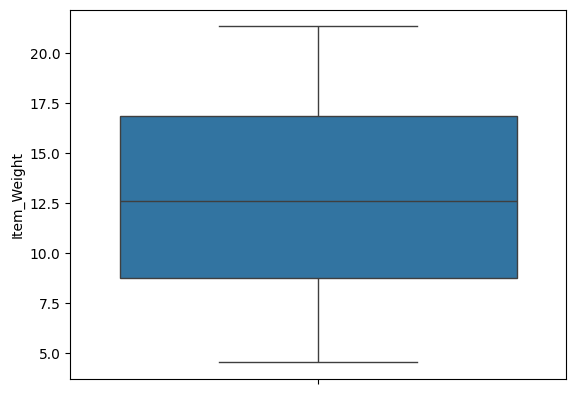

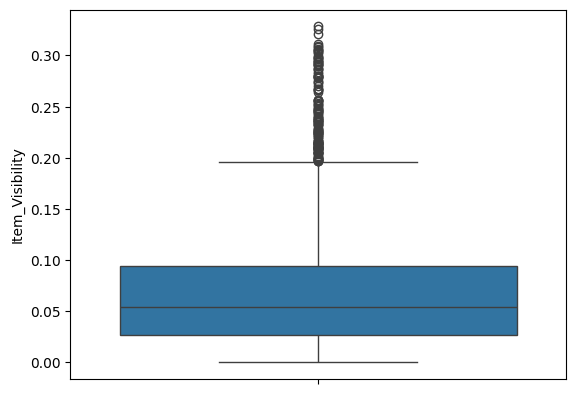

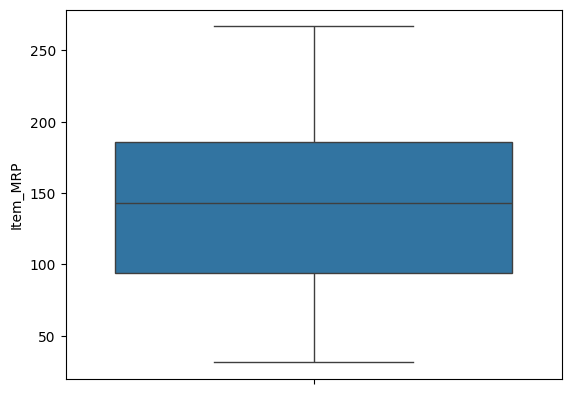

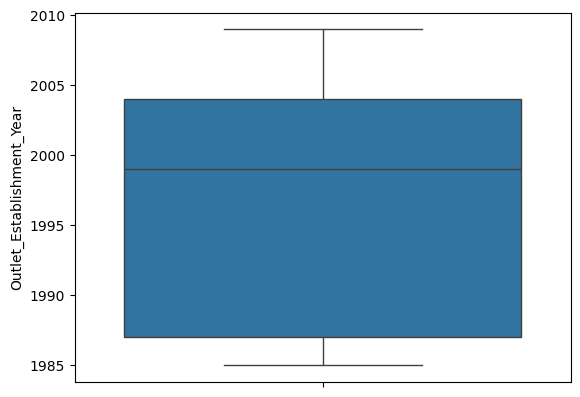

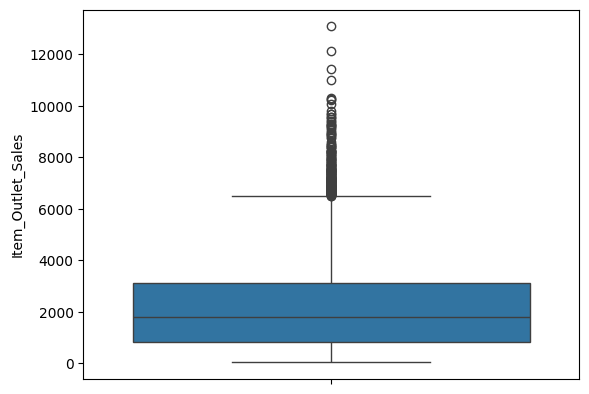

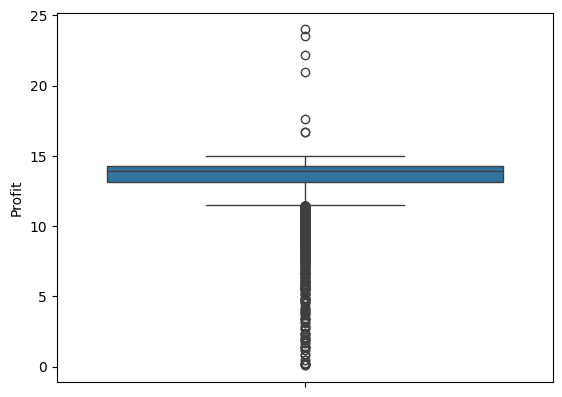

In [70]:
for i in data_num.columns:
    sns.boxplot(data_num[i])
    plt.show()

In [71]:
# drop the outliers:

datacheck=data_num.copy()
q1=datacheck["Item_Outlet_Sales"].quantile(0.25) # 25th percentile

q3=datacheck["Item_Outlet_Sales"].quantile(0.75)  #75th perecentile

iqr=q3-q1

UB=q3 +1.5*(iqr)

LB=q1-1.5*(iqr)

cleaneddata= datacheck[(datacheck["Item_Outlet_Sales"] >= LB) & (datacheck["Item_Outlet_Sales"] <= UB)]


<Axes: ylabel='Item_Outlet_Sales'>

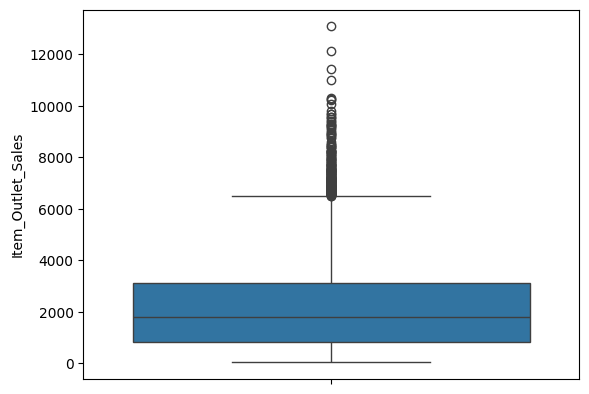

In [72]:
sns.boxplot(data_num["Item_Outlet_Sales"])

<Axes: ylabel='Item_Outlet_Sales'>

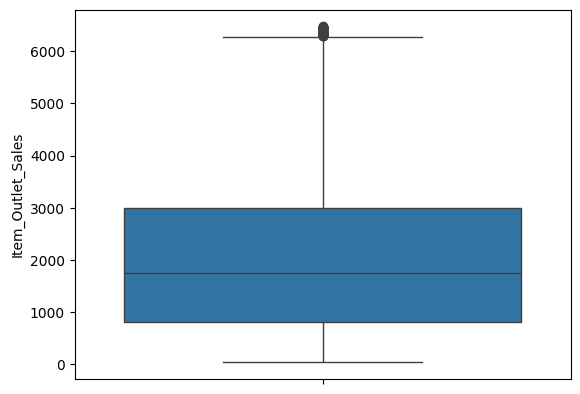

In [73]:
sns.boxplot(cleaneddata["Item_Outlet_Sales"])

In [74]:
cleaneddata.isnull().sum()

Item_Weight                  1360
Item_Visibility                 0
Item_MRP                        0
Outlet_Establishment_Year       0
Item_Outlet_Sales               0
Profit                          0
dtype: int64

In [75]:
cleaneddata.shape

(8337, 6)

In [76]:
# Outlier treatemnt for Item Outlet sale
q1=data_num["Item_Outlet_Sales"].quantile(0.25) # 25th percentile

q3=data_num["Item_Outlet_Sales"].quantile(0.75)  #75th perecentile

iqr=q3-q1

UB=q3 +1.5*(iqr)

LB=q1-1.5*(iqr)

print(LB,UB)

-2566.3261 6501.8699


In [77]:
data_num["Item_Outlet_Sales"]=np.where(data_num["Item_Outlet_Sales"]<LB,LB,data_num["Item_Outlet_Sales"])

data_num["Item_Outlet_Sales"]=np.where(data_num["Item_Outlet_Sales"]>UB,UB,data_num["Item_Outlet_Sales"])



<Axes: ylabel='Item_Outlet_Sales'>

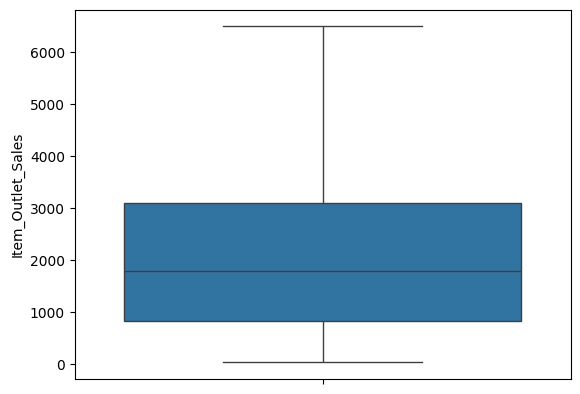

In [78]:
sns.boxplot(data_num["Item_Outlet_Sales"])

In [79]:
#For all columns same approach
for i in data_num.columns:
    
    q1=data[i].quantile(0.25)

    q3=data[i].quantile(0.75)

    iqr=q3-q1

    UB= q3+1.5*iqr

    LB =q1-1.5*iqr
    
    data_num[i]=np.where(data_num[i]>UB, UB, data_num[i])

    data_num[i]=np.where(data_num[i]<LB, LB, data_num[i])
    

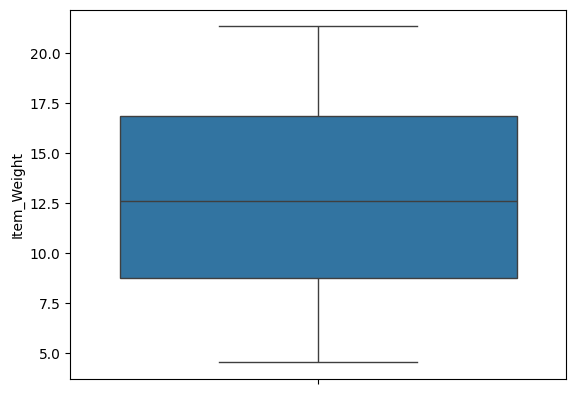

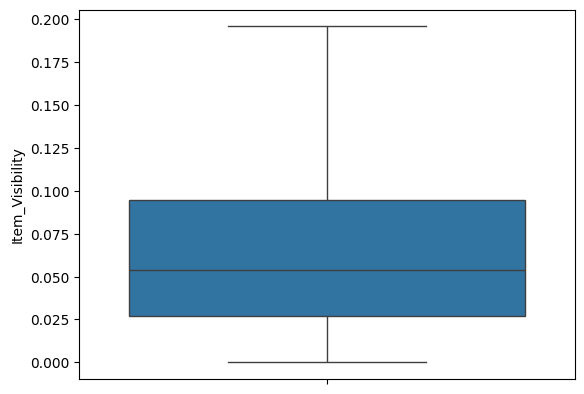

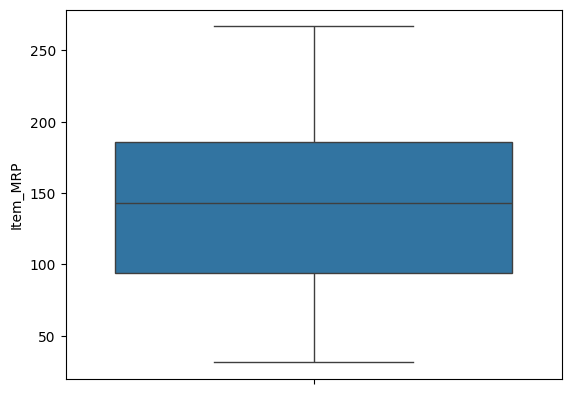

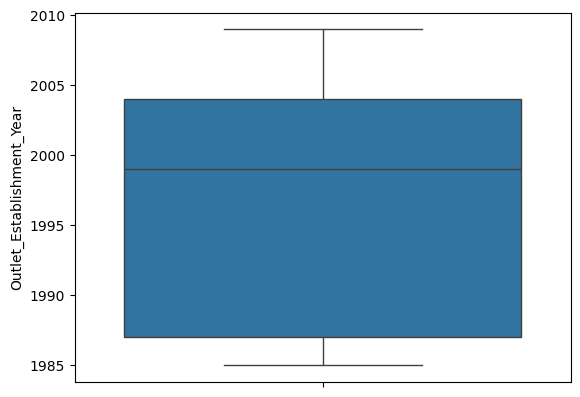

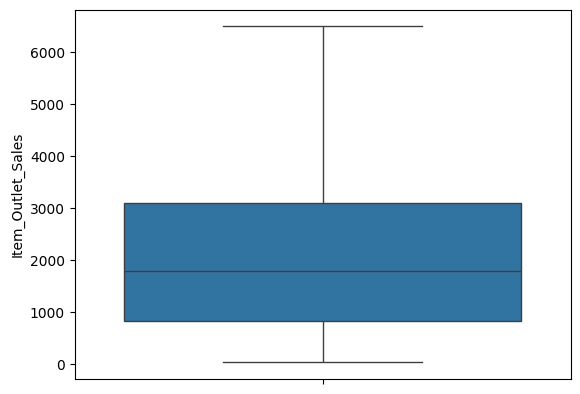

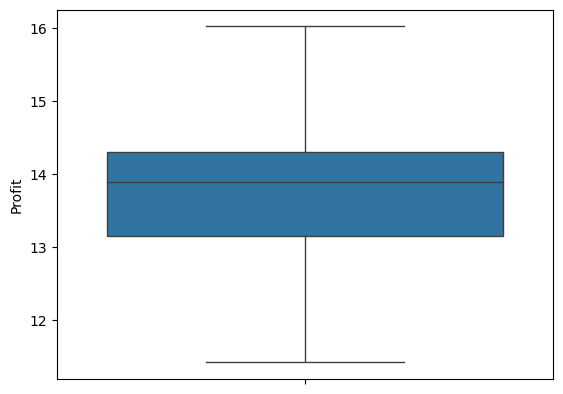

In [80]:
for i in data_num.columns:
    sns.boxplot(data_num[i])
    plt.show()

In [81]:
import sklearn
sklearn.__version__


'1.6.1'

# Scaling or Normalization

In [82]:
datanum=data_new.select_dtypes(include=np.number)
datanum.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
0,9.30,0.016047,249.8,1999,3735.1380,11.5
1,5.92,0.019278,48.3,2009,443.4228,14.3
2,17.50,0.016760,141.6,1999,2097.2700,14.5
3,19.20,0.000000,182.1,1998,732.3800,13.6
4,8.93,0.000000,53.9,1987,994.7052,14.1


In [83]:
datanum.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.998838,1997.831867,2181.288914,13.414514
std,4.643456,0.051598,62.258099,8.371760,1706.499616,1.701840
min,4.555000,0.000000,31.300000,1985.000000,33.290000,0.100000
25%,8.773750,0.026989,93.800000,1987.000000,834.247400,13.150000
50%,12.600000,0.053931,142.700000,1999.000000,1794.331000,13.900000
75%,16.850000,0.094585,185.650000,2004.000000,3101.296400,14.300000
max,21.350000,0.328391,266.900000,2009.000000,13086.964800,24.000000


In [84]:
# standard scalar
#sklearn------------Scikit learn

from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

datanum_sc=sc.fit_transform(datanum)

In [85]:
datanum_sc

array([[-0.7662174 , -0.97073217,  1.74768499,  0.13954076,  0.910601  ,
        -1.12503308],
       [-1.49417499, -0.90811123, -1.48903161,  1.33410274, -1.01844035,
         0.52034176],
       [ 0.99983356, -0.95691733,  0.00965652,  0.13954076, -0.04923754,
         0.63786854],
       ...,
       [-0.48623371, -0.59978449, -0.89790917,  0.73682175, -0.57909963,
        -2.30030082],
       [-1.21634502,  1.53287976, -0.6087732 ,  1.33410274, -0.19672492,
         0.46157837],
       [ 0.41832897, -0.41193591, -1.05211502, -0.09937163, -0.82959407,
         0.69663192]], shape=(8523, 6))

In [86]:
datanum_sc=pd.DataFrame(datanum_sc)


datanum_sc.columns=datanum.columns
datanum_sc

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
0,-0.766217,-0.970732,1.747685,0.139541,0.910601,-1.125033
1,-1.494175,-0.908111,-1.489032,1.334103,-1.018440,0.520342
2,0.999834,-0.956917,0.009657,0.139541,-0.049238,0.637869
3,1.365966,-1.281758,0.660212,0.020085,-0.849103,0.108998
4,-0.845905,-1.281758,-1.399078,-1.293934,-0.695373,0.402815
...,...,...,...,...,...,...
8518,-1.290648,-0.181193,1.180657,-1.293934,0.349915,0.402815
8519,-0.964360,-0.371154,-0.526851,0.497909,-0.956402,0.461578
8520,-0.486234,-0.599784,-0.897909,0.736822,-0.579100,-2.300301
8521,-1.216345,1.532880,-0.608773,1.334103,-0.196725,0.461578


In [87]:
datanum_sc

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
0,-0.766217,-0.970732,1.747685,0.139541,0.910601,-1.125033
1,-1.494175,-0.908111,-1.489032,1.334103,-1.018440,0.520342
2,0.999834,-0.956917,0.009657,0.139541,-0.049238,0.637869
3,1.365966,-1.281758,0.660212,0.020085,-0.849103,0.108998
4,-0.845905,-1.281758,-1.399078,-1.293934,-0.695373,0.402815
...,...,...,...,...,...,...
8518,-1.290648,-0.181193,1.180657,-1.293934,0.349915,0.402815
8519,-0.964360,-0.371154,-0.526851,0.497909,-0.956402,0.461578
8520,-0.486234,-0.599784,-0.897909,0.736822,-0.579100,-2.300301
8521,-1.216345,1.532880,-0.608773,1.334103,-0.196725,0.461578


In [88]:
datanum_sc.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7.060000e+03,8.523000e+03,8.523000e+03,8.523000e+03,8.523000e+03,8.523000e+03
mean,4.060963e-16,-1.092117e-16,4.460171e-17,1.156560e-14,1.638175e-16,1.850762e-16
std,1.000071e+00,1.000059e+00,1.000059e+00,1.000059e+00,1.000059e+00,1.000059e+00
min,-1.788158e+00,-1.281758e+00,-1.762104e+00,-1.532846e+00,-1.258790e+00,-7.824059e+00
25%,-8.795570e-01,-7.586531e-01,-7.581601e-01,-1.293934e+00,-7.894057e-01,-1.554372e-01
50%,-5.548958e-02,-2.364792e-01,2.732594e-02,1.395408e-01,-2.267687e-01,2.852882e-01
75%,8.598417e-01,5.514755e-01,7.172365e-01,7.368218e-01,5.391513e-01,5.203418e-01
max,1.829016e+00,5.083050e+00,2.022364e+00,1.334103e+00,6.391045e+00,6.220390e+00


<Axes: ylabel='Profit'>

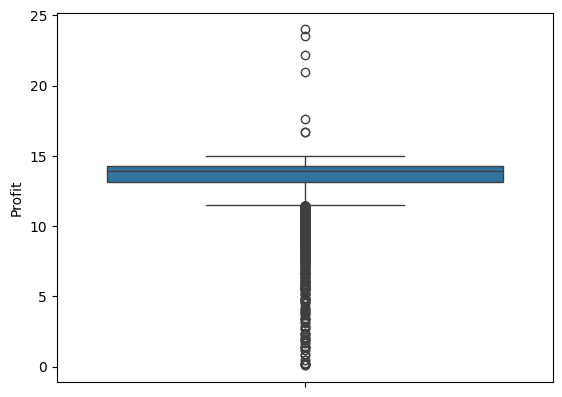

In [89]:
import seaborn as sns
sns.boxplot(datanum["Profit"])

In [90]:
# Minmax scalar
from sklearn.preprocessing import MinMaxScaler

mm=MinMaxScaler()

mm_scale=mm.fit_transform(datanum)

datanum_mm=pd.DataFrame(mm_scale)



datanum_mm.columns=datanum.columns

In [91]:
datanum_mm

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
0,0.282525,0.048866,0.927419,0.583333,0.283587,0.476987
1,0.081274,0.058705,0.072156,1.000000,0.031419,0.594142
2,0.770765,0.051037,0.468166,0.583333,0.158115,0.602510
3,0.871986,0.000000,0.640068,0.541667,0.053555,0.564854
4,0.260494,0.000000,0.095925,0.083333,0.073651,0.585774
...,...,...,...,...,...,...
8518,0.137541,0.172914,0.777589,0.083333,0.210293,0.585774
8519,0.227746,0.143069,0.326401,0.708333,0.039529,0.589958
8520,0.359929,0.107148,0.228353,0.791667,0.088850,0.393305
8521,0.158083,0.442219,0.304754,1.000000,0.138835,0.589958


In [92]:
datanum_mm.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Profit
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,0.494352,0.201382,0.465615,0.534661,0.164551,0.557093
std,0.276479,0.157123,0.264253,0.348823,0.130729,0.071207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.251191,0.082187,0.265280,0.083333,0.061359,0.546025
50%,0.479012,0.164228,0.472835,0.583333,0.134908,0.577406
75%,0.732063,0.288026,0.655136,0.791667,0.235030,0.594142
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Encoding Techniques

In [93]:
data6=data_new.copy()

In [94]:
data6.dropna(inplace=True)

In [95]:
data6["Outlet_Size"].nunique()

3

In [96]:
data6["Outlet_Size"]

0       Medium
1       Medium
2       Medium
4         High
5       Medium
         ...  
8517     Small
8518      High
8520     Small
8521    Medium
8522     Small
Name: Outlet_Size, Length: 4650, dtype: object

In [97]:
data6["Outlet_Size"].unique()

array(['Medium', 'High', 'Small'], dtype=object)

In [98]:
# one hot encoding
x=pd.get_dummies(data6["Outlet_Size"],drop_first=True)
x

,Medium,Small
0,True,False
1,True,False
2,True,False
4,False,False
5,True,False
...,...,...
8517,False,True
8518,False,False
8520,False,True
8521,True,False


In [99]:
# Label encoder

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

data6["Outlesize_le"]=le.fit_transform(data6["Outlet_Size"])

In [100]:
data6.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Outlesize_le
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,1
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,1
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,1
4,NCD19,8.930,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,0
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4,OUT018,2009,Medium,Tier 2,Supermarket Type2,556.6088,9.5,1


In [101]:
data6[["Outlet_Size","Outlesize_le"]]

,Outlet_Size,Outlesize_le
0,Medium,1
1,Medium,1
2,Medium,1
4,High,0
5,Medium,1
...,...,...
8517,Small,2
8518,High,0
8520,Small,2
8521,Medium,1


In [102]:
# ordinal Encoder-----> follow the order

from sklearn.preprocessing import OrdinalEncoder

ode= OrdinalEncoder(categories=[["Small","Medium","High"]])

data6["Outletsize_ode"]=ode.fit_transform(data6[["Outlet_Size"]])

In [103]:
data6[["Outlet_Size","Outlesize_le","Outletsize_ode"]]

,Outlet_Size,Outlesize_le,Outletsize_ode
0,Medium,1,1.0
1,Medium,1,1.0
2,Medium,1,1.0
4,High,0,2.0
5,Medium,1,1.0
...,...,...,...
8517,Small,2,0.0
8518,High,0,2.0
8520,Small,2,0.0
8521,Medium,1,1.0


In [104]:
data6[["Outlet_Size"]].shape

(4650, 1)

In [105]:
data6["Outlet_Size"].shape

(4650,)